In [6]:
# ==========================================================
# DeepONet
# Antibody Binding Kinetics
# Google Colab
# ==========================================================

!pip install -q tensorflow
!pip install -q scipy
!pip install -q matplotlib
!pip install -q pandas
!pip install -q tqdm

In [7]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from tqdm import tqdm

print("TensorFlow Version:", tf.__version__)

tf.keras.backend.set_floatx("float32")

np.random.seed(42)
tf.random.set_seed(42)

TensorFlow Version: 2.20.0


In [8]:
# ==========================================================
# Physical Parameters
# ==========================================================

D = 1e-10

kf = 1e5

kr = 1e-2

cb_sat = 2.66e-8
c_bulk = 4.48e-5

h = 5e-5

t0 = 0.0

tfinal = 500.0

In [9]:
# ==========================================================
# DeepONet Hyperparameters
# ==========================================================

# Training
EPOCHS = 1000
LEARNING_RATE = 1e-3
BATCH_SIZE = 32

# Network Architecture
LATENT_DIM = 100

# Branch Network (Physical Parameters)
BRANCH_NEURONS = 128

# Trunk Network (Spatial & Temporal Coordinates)
TRUNK_NEURONS = 128

# Output
# Predicts concentration c(z,t)
OUTPUT_DIM = 1

In [11]:
import numpy as np
from google.colab import drive # Added import

# ----------------------------------------------------------
# Path to the numerical solver files
# ----------------------------------------------------------

DATA_PATH = "/content/drive/MyDrive/"   # <-- Change if needed

# ----------------------------------------------------------
# Mount Google Drive if not already mounted (added for fix)
# ----------------------------------------------------------
try:
    drive.mount('/content/drive', force_remount=True)
except Exception as e:
    print(f"Could not mount Google Drive: {e}. Please ensure you authorize access.")

# ----------------------------------------------------------
# Load numerical solver results
# ----------------------------------------------------------

coordinates = np.load(DATA_PATH + "coordinates.npy")
concentration = np.load(DATA_PATH + "concentration.npy")
binding = np.load(DATA_PATH + "binding.npy")

# ----------------------------------------------------------
# Number of samples
# ----------------------------------------------------------

N = coordinates.shape[0]

# ----------------------------------------------------------
# Branch Input
# Physical parameters
# ----------------------------------------------------------

params = np.array([
    D,
    kf,
    kr,
    cb_sat,
    c_bulk
], dtype=np.float32)

branch_input = np.tile(params, (N,1))

# ----------------------------------------------------------
# Trunk Input
# (z,t) coordinates
# ----------------------------------------------------------

trunk_input = coordinates.astype(np.float32)

# ----------------------------------------------------------
# Target Output
# Numerical concentration
# ----------------------------------------------------------

targets = concentration.reshape(-1,1).astype(np.float32)

print("="*60)
print("DeepONet Dataset Loaded")
print("="*60)
print("Branch Input :", branch_input.shape)
print("Trunk Input  :", trunk_input.shape)
print("Targets      :", targets.shape)
print("="*60)

Mounted at /content/drive
DeepONet Dataset Loaded
Branch Input : (420000, 5)
Trunk Input  : (420000, 2)
Targets      : (420000, 1)


In [12]:
dataset = tf.data.Dataset.from_tensor_slices(

    (
        (
            branch_input,
            trunk_input
        ),
        targets
    )
)

dataset = dataset.shuffle(5000)

dataset = dataset.batch(BATCH_SIZE)

print(dataset)

<_BatchDataset element_spec=((TensorSpec(shape=(None, 5), dtype=tf.float32, name=None), TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>


In [13]:
# ==========================================================
# Branch Network
# ==========================================================

branch_inputs = tf.keras.Input(shape=(5,))

x = tf.keras.layers.Dense(
    BRANCH_NEURONS,
    activation="tanh"
)(branch_inputs)

x = tf.keras.layers.Dense(
    BRANCH_NEURONS,
    activation="tanh"
)(x)

x = tf.keras.layers.Dense(
    LATENT_DIM,
    activation="linear"
)(x)

branch_model = tf.keras.Model(
    branch_inputs,
    x
)

# ==========================================================
# Trunk Network
# ==========================================================

trunk_inputs = tf.keras.Input(shape=(2,))

y = tf.keras.layers.Dense(
    TRUNK_NEURONS,
    activation="tanh"
)(trunk_inputs)

y = tf.keras.layers.Dense(
    TRUNK_NEURONS,
    activation="tanh"
)(y)

y = tf.keras.layers.Dense(
    LATENT_DIM,
    activation="linear"
)(y)

trunk_model = tf.keras.Model(
    trunk_inputs,
    y
)

# ==========================================================
# DeepONet Model
# ==========================================================

class DeepONet(tf.keras.Model):

    def __init__(self):

        super().__init__()

        self.branch = branch_model

        self.trunk = trunk_model

    def call(self, inputs):

        branch_input, trunk_input = inputs

        B = self.branch(branch_input)

        T = self.trunk(trunk_input)

        output = tf.reduce_sum(B*T, axis=1, keepdims=True)

        return output

model = DeepONet()

print(model)

<DeepONet name=deep_o_net, built=False>


In [14]:
# ==========================================================
# Step 8 : Loss Function and Optimizer
# ==========================================================

loss_fn = tf.keras.losses.MeanSquaredError()

optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE
)

print("Optimizer Initialized")

Optimizer Initialized


In [15]:
# ==========================================================
# Step 9 : One Training Step
# ==========================================================

@tf.function
def train_step(branch_batch,
               trunk_batch,
               target_batch):

    with tf.GradientTape() as tape:

        prediction = model(
            (
                branch_batch,
                trunk_batch
            ),
            training=True
        )

        loss = loss_fn(
            target_batch,
            prediction
        )

    gradients = tape.gradient(
        loss,
        model.trainable_variables
    )

    optimizer.apply_gradients(
        zip(
            gradients,
            model.trainable_variables
        )
    )

    return loss

In [16]:
# ==========================================================
# Step 10 : Training Loop
# ==========================================================

loss_history = []

print("Starting Training...\n")

for epoch in range(EPOCHS):

    epoch_loss = 0.0

    batches = 0

    for (branch_batch,
         trunk_batch), target_batch in dataset:

        loss = train_step(
            branch_batch,
            trunk_batch,
            target_batch
        )

        epoch_loss += loss.numpy()

        batches += 1

    epoch_loss /= batches

    loss_history.append(epoch_loss)

    if epoch % 20 == 0:

        print(
            f"Epoch {epoch:4d} | Loss = {epoch_loss:.6e}"
        )

print("\nTraining Finished")

Starting Training...

Epoch    0 | Loss = 2.453107e-01
Epoch   20 | Loss = 1.384108e-01
Epoch   40 | Loss = 3.986620e-01
Epoch   60 | Loss = 7.422742e-02
Epoch   80 | Loss = 6.434747e-04
Epoch  100 | Loss = 1.779624e-01
Epoch  120 | Loss = 2.267086e-01
Epoch  140 | Loss = 1.195935e-01
Epoch  160 | Loss = 1.259326e-04
Epoch  180 | Loss = 5.476148e-02
Epoch  200 | Loss = 1.021746e-01
Epoch  220 | Loss = 8.873223e-02
Epoch  240 | Loss = 2.549667e-02
Epoch  260 | Loss = 6.185622e-02
Epoch  280 | Loss = 1.566811e-05
Epoch  300 | Loss = 2.475897e-01
Epoch  320 | Loss = 3.810134e-05
Epoch  340 | Loss = 1.591439e-01
Epoch  360 | Loss = 9.148162e-02
Epoch  380 | Loss = 1.552111e-01
Epoch  400 | Loss = 1.696127e-04
Epoch  420 | Loss = 1.903751e-04
Epoch  440 | Loss = 9.065939e-05
Epoch  460 | Loss = 1.228439e-01
Epoch  480 | Loss = 1.750707e-01
Epoch  500 | Loss = 1.989262e-01
Epoch  520 | Loss = 6.652625e-02
Epoch  540 | Loss = 1.143469e-04
Epoch  560 | Loss = 3.225672e-01
Epoch  580 | Loss = 1

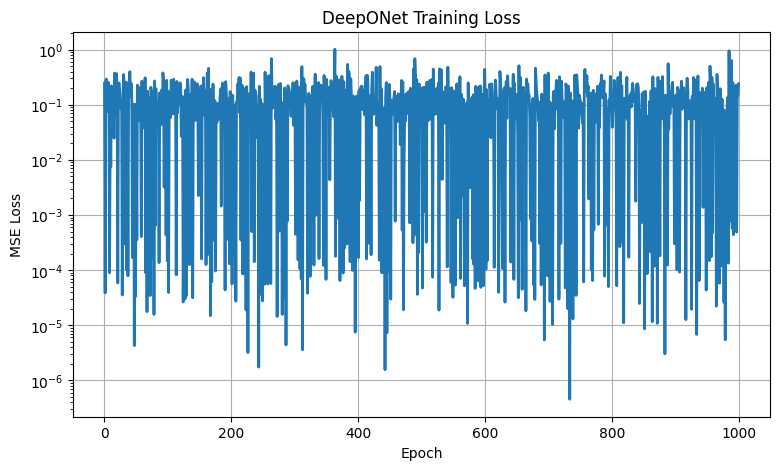

In [17]:
# ==========================================================
# Step 11 : Plot Training History
# ==========================================================

plt.figure(figsize=(9,5))

plt.plot(
    loss_history,
    linewidth=2
)

plt.yscale("log")

plt.xlabel("Epoch")

plt.ylabel("MSE Loss")

plt.title("DeepONet Training Loss")

plt.grid(True)

plt.show()

In [18]:
# ==========================================================
# Step 12 : Prediction Function
# ==========================================================

def predict(branch,
            trunk):

    prediction = model.predict(
        (
            branch,
            trunk
        ),
        verbose=0
    )

    return prediction

In [19]:
sample_branch = branch_input[:5]

sample_trunk = trunk_input[:5]

prediction = predict(
    sample_branch,
    sample_trunk
)

print(prediction)

[[0.07197703]
 [0.07198004]
 [0.07198283]
 [0.0719857 ]
 [0.07198837]]


In [20]:
# ==========================================================
# Step 13 : Evaluate Model
# ==========================================================

prediction = predict(
    branch_input,
    trunk_input
)

mse = np.mean(

    (prediction-targets)**2

)

mae = np.mean(

    np.abs(prediction-targets)

)

relative_error = np.linalg.norm(

    prediction-targets

)/np.linalg.norm(targets)

print("="*60)

print("DeepONet Evaluation")

print("="*60)

print(f"MSE            : {mse:.6e}")

print(f"MAE            : {mae:.6e}")

print(f"Relative Error : {relative_error:.6e}")

print("="*60)

DeepONet Evaluation
MSE            : 1.239538e-02
MAE            : 2.645822e-02
Relative Error : 3.252093e+03


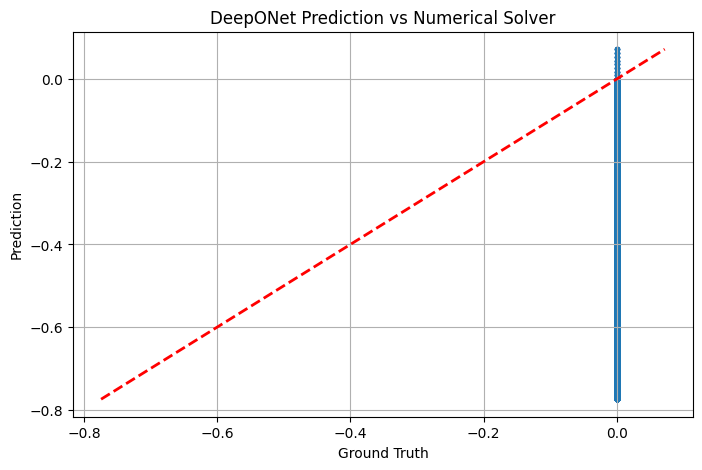

In [21]:
# ==========================================================
# Step 14 : Visualization
# ==========================================================

plt.figure(figsize=(8,5))

plt.scatter(
    targets,
    prediction,
    alpha=0.4,
    s=8
)

min_val = min(targets.min(), prediction.min())
max_val = max(targets.max(), prediction.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2
)

plt.xlabel("Ground Truth")
plt.ylabel("Prediction")
plt.title("DeepONet Prediction vs Numerical Solver")
plt.grid(True)

plt.show()

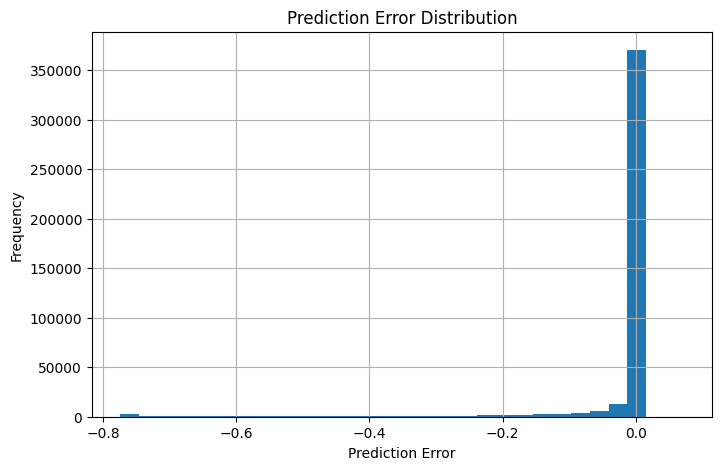

In [22]:
errors = prediction - targets

plt.figure(figsize=(8,5))

plt.hist(
    errors,
    bins=30
)

plt.xlabel("Prediction Error")

plt.ylabel("Frequency")

plt.title("Prediction Error Distribution")

plt.grid(True)

plt.show()

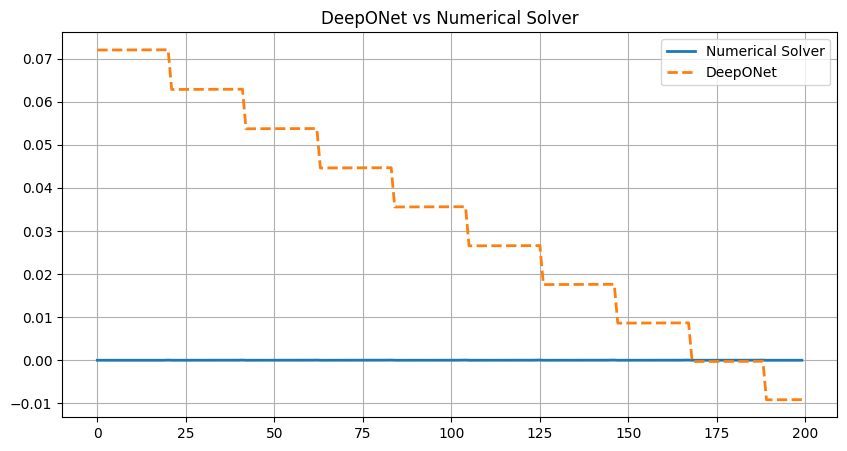

In [23]:
plt.figure(figsize=(10,5))

plt.plot(
    targets[:200],
    label="Numerical Solver",
    linewidth=2
)

plt.plot(
    prediction[:200],
    '--',
    label="DeepONet",
    linewidth=2
)

plt.legend()
plt.grid(True)
plt.title("DeepONet vs Numerical Solver")

plt.show()

In [24]:
# ==========================================================
# Step 15 : Save Model
# ==========================================================

model.save_weights(
    "DeepONet_Model.weights.h5"
)

print("Model Saved Successfully")

Model Saved Successfully


In [25]:
new_model = DeepONet()

new_model(
    (
        tf.zeros((1,5)),
        tf.zeros((1,2))
    )
)

new_model.load_weights(
    "DeepONet_Model.weights.h5"
)

print("Weights Loaded")

Weights Loaded


In [26]:
# ==========================================================
# Step 16 : Save Results
# ==========================================================

history = pd.DataFrame({

    "Training Loss":loss_history

})

history.to_csv(

    "DeepONet_Training_History.csv",

    index=False

)

In [27]:
results = pd.DataFrame({

    "Ground Truth":targets.flatten(),

    "Prediction":prediction.flatten(),

    "Absolute Error":np.abs(

        prediction.flatten()-targets.flatten()

    )

})

results.to_csv(

    "DeepONet_Predictions.csv",

    index=False

)

print("CSV Files Saved")

CSV Files Saved


In [28]:
# ==========================================================
# Step 17 : Final Report
# ==========================================================

print("="*70)
print("               DEEPONET FINAL REPORT")
print("="*70)

print("\nModel")
print("-"*70)
print("Architecture        : DeepONet")
print("Training Data       : Numerical Solver")
print("Branch Inputs       : Physical Parameters")
print("Trunk Inputs        : (z, t)")
print("Output              : Concentration c(z,t)")
print("Latent Dimension    :", LATENT_DIM)

print("\nTraining")
print("-"*70)
print("Epochs              :", EPOCHS)
print("Learning Rate       :", LEARNING_RATE)
print("Batch Size          :", BATCH_SIZE)

print("\nPerformance")
print("-"*70)
print(f"Final Loss          : {loss_history[-1]:.6e}")
print(f"MSE                 : {mse:.6e}")
print(f"MAE                 : {mae:.6e}")
print(f"Relative Error      : {relative_error:.6e}")

print("\nGenerated Files")
print("-"*70)
print("✓ DeepONet_Model.weights.h5")
print("✓ DeepONet_Training_History.csv")
print("✓ DeepONet_Predictions.csv")

print("="*70)
print("DeepONet trained using Numerical Solver dataset")
print("="*70)

               DEEPONET FINAL REPORT

Model
----------------------------------------------------------------------
Architecture        : DeepONet
Training Data       : Numerical Solver
Branch Inputs       : Physical Parameters
Trunk Inputs        : (z, t)
Output              : Concentration c(z,t)
Latent Dimension    : 100

Training
----------------------------------------------------------------------
Epochs              : 1000
Learning Rate       : 0.001
Batch Size          : 32

Performance
----------------------------------------------------------------------
Final Loss          : 2.402913e-01
MSE                 : 1.239538e-02
MAE                 : 2.645822e-02
Relative Error      : 3.252093e+03

Generated Files
----------------------------------------------------------------------
✓ DeepONet_Model.weights.h5
✓ DeepONet_Training_History.csv
✓ DeepONet_Predictions.csv
DeepONet trained using Numerical Solver dataset
